<a href="https://colab.research.google.com/github/jakkulaayushpreetham/University-Placement-Outcomes-Analysis-/blob/main/EDAV(PLACEMENTS_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



print("\n📘 Loading Dataset...")
df = pd.read_excel("placements_dataset.xlsx")
print(f"✅ Dataset Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} columns")



print("\n⚙️ Preprocessing Data...")


def placed_to_binary(x):
    if str(x).lower() in ['yes', 'y', '1', 'true', 'placed']:
        return 1
    return 0


df['placed'] = df['placed'].apply(placed_to_binary)
df['internships'] = df['internships'].fillna(0).astype(int)
df['certifications'] = df['certifications'].fillna(0).astype(int)


# Winsorize ctc_lpa at 1st and 99th percentile
lower, upper = df['ctc_lpa'].quantile([0.01, 0.99])
df['ctc_lpa'] = df['ctc_lpa'].clip(lower, upper)
print(f"✅ Winsorization Done → Lower Limit: {lower:.2f}, Upper Limit: {upper:.2f}")


📘 Loading Dataset...
✅ Dataset Loaded Successfully: 300 rows, 7 columns

⚙️ Preprocessing Data...
✅ Winsorization Done → Lower Limit: 2.00, Upper Limit: 10.12


# Q1: Placement Rate by Department

In [ ]:
print("\n📊 Q1: Placement Rate by Department")
q1 = df.groupby('dept')['placed'].agg(['count', 'sum'])
q1['Placement Rate (%)'] = (q1['sum'] / q1['count'] * 100).round(2)
print(q1.sort_values('Placement Rate (%)', ascending=False))


📊 Q1: Placement Rate by Department
       count  sum  Placement Rate (%)
dept                                 
EEE       52   38               73.08
ECE       42   29               69.05
CSE       57   37               64.91
MECH      64   41               64.06
CIVIL     39   23               58.97
IT        46   27               58.70


# Q2: CGPA Buckets vs Placement & Median CTC

In [ ]:
print("\n📈 Q2: CGPA Buckets vs Placement & Median CTC")
bins = [4, 6, 7, 8, 9, 10]
labels = ['4-6', '6-7', '7-8', '8-9', '9-10']
df['cgpa_bucket'] = pd.cut(df['cgpa'], bins=bins, labels=labels, include_lowest=True)
q2 = df.groupby('cgpa_bucket').agg(
Total=('student_id', 'count'),
Placed=('placed', 'sum'),
Median_CTC=('ctc_lpa', 'median')
)
q2['Placement Rate (%)'] = (q2['Placed'] / q2['Total'] * 100).round(2)
print(q2)


📈 Q2: CGPA Buckets vs Placement & Median CTC
             Total  Placed  Median_CTC  Placement Rate (%)
cgpa_bucket                                               
4-6             53      34       5.550               64.15
6-7             76      44       5.305               57.89
7-8             59      41       5.550               69.49
8-9             52      35       5.785               67.31
9-10            60      41       5.730               68.33


/tmp/ipython-input-1607157568.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q2 = df.groupby('cgpa_bucket').agg(


# Q3: Replace Missing Internships/Certifications

In [ ]:

print("\n🧹 Q3: Missing Value Handling")

internships_missing_before = df['internships'].isna().sum()
certifications_missing_before = df['certifications'].isna().sum()

internships_missing_after = df['internships'].fillna(0).isna().sum()
certifications_missing_after = df['certifications'].fillna(0).isna().sum()

print(f"Internships Missing Before: {internships_missing_before} → After: {internships_missing_after}")
print(f"Certifications Missing Before: {certifications_missing_before} → After: {certifications_missing_after}")
print("✅ All missing values replaced with 0")
df['internships'] = df['internships'].fillna(0)
df['certifications'] = df['certifications'].fillna(0)


print(df[['student_id', 'internships', 'certifications']].head(10))



🧹 Q3: Missing Value Handling
Internships Missing Before: 0 → After: 0
Certifications Missing Before: 0 → After: 0
✅ All missing values replaced with 0
  student_id  internships  certifications
0       S001            0               0
1       S002            0               3
2       S003            3               4
3       S004            0               0
4       S005            1               0
5       S006            3               0
6       S007            0               0
7       S008            2               3
8       S009            1               1
9       S010            0               1


# Q4: Correlations and Regression

In [ ]:
print("\n📉 Q4: Correlation and Linear Regression")
features = ['internships', 'certifications', 'cgpa']
X = df[features]
y = df['ctc_lpa']
correlations = df[features + ['ctc_lpa']].corr()['ctc_lpa'].drop('ctc_lpa')
print("\n📊 Pearson Correlations with CTC:")
print(correlations.round(3))

model = LinearRegression()
model.fit(X, y)
r2 = r2_score(y, model.predict(X))
print("\n📈 Regression Model Summary:")
for feat, coef in zip(features, model.coef_):
    print(f"{feat}: {coef:.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"R² Score: {r2:.3f}")


📉 Q4: Correlation and Linear Regression

📊 Pearson Correlations with CTC:
internships      -0.049
certifications    0.006
cgpa              0.035
Name: ctc_lpa, dtype: float64

📈 Regression Model Summary:
internships: -0.104
certifications: 0.011
cgpa: 0.045
Intercept: 5.197
R² Score: 0.003


# Visualization (Department-wise Placement Rate Graph)

/tmp/ipython-input-1352661837.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipython-input-1352661837.py:29: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


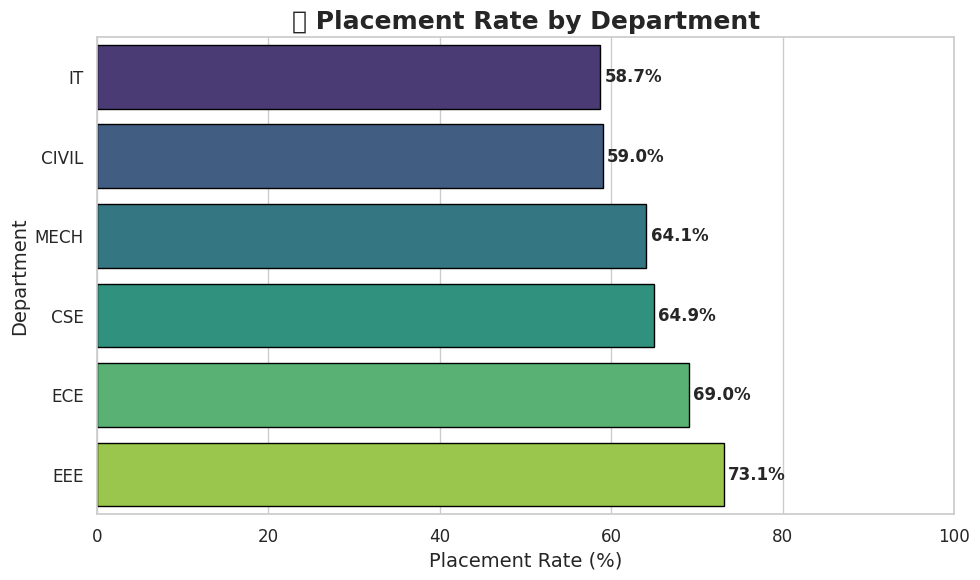

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid", palette="viridis", font_scale=1.1)


dept_summary = df.groupby('dept')['placed'].mean().reset_index()
dept_summary['Placement Rate (%)'] = (dept_summary['placed'] * 100).round(2)

plt.figure(figsize=(10,6))
bars = sns.barplot(
    y='dept', x='Placement Rate (%)',
    data=dept_summary.sort_values('Placement Rate (%)', ascending=True),
    palette=sns.color_palette("viridis", n_colors=len(dept_summary)),
    edgecolor='black'
)

plt.title("📊 Placement Rate by Department", fontsize=18, weight='bold')
plt.xlabel("Placement Rate (%)", fontsize=14)
plt.ylabel("Department", fontsize=14)

for p in bars.patches:
    bars.annotate(f"{p.get_width():.1f}%",
                  (p.get_width() + 0.5, p.get_y() + p.get_height() / 2),
                  ha='left', va='center', fontsize=12, weight='bold')

plt.xlim(0, 100)
plt.tight_layout()
plt.show()


# Visualization (CGPA vs CTC Scatter Plot)

/tmp/ipython-input-173981863.py:36: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


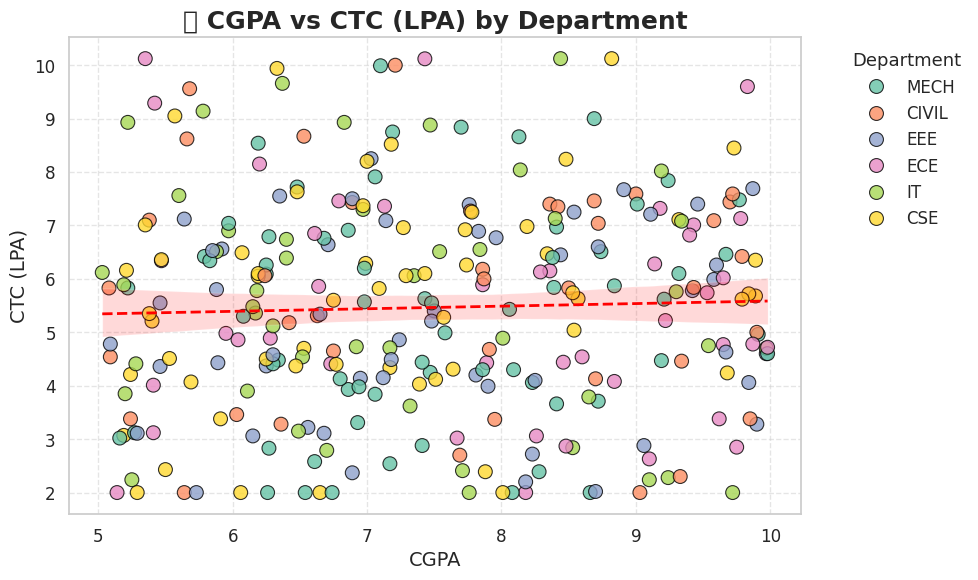

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10,6))


sns.scatterplot(
    data=df,
    x='cgpa', y='ctc_lpa',
    hue='dept',
    palette="Set2",
    s=100,
    edgecolor='black',
    alpha=0.8
)


sns.regplot(
    data=df, x='cgpa', y='ctc_lpa',
    scatter=False,
    ci=95,
    line_kws={'color':'red', 'lw':2, 'linestyle':'--'}
)


plt.title("💰 CGPA vs CTC (LPA) by Department", fontsize=18, weight='bold')
plt.xlabel("CGPA", fontsize=14)
plt.ylabel("CTC (LPA)", fontsize=14)


plt.legend(title="Department", fontsize=12, title_fontsize=13, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


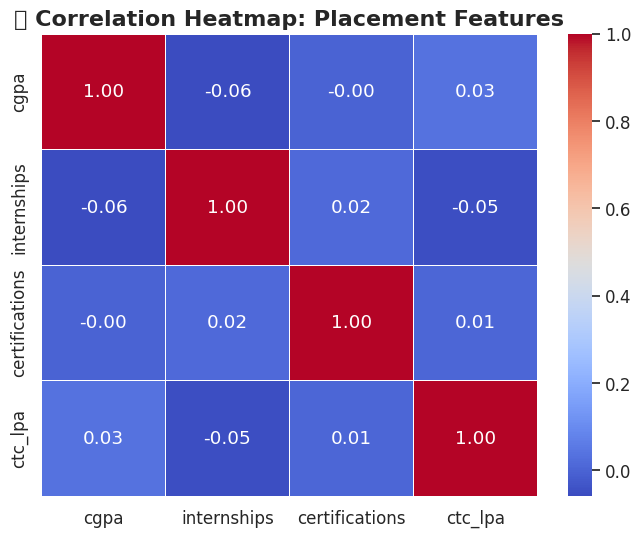

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = df[['cgpa', 'internships', 'certifications', 'ctc_lpa']].corr()


plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("📊 Correlation Heatmap: Placement Features", fontsize=16, weight='bold')
plt.show()
